<a href="https://colab.research.google.com/github/JakiyaStar/DepthNet/blob/main/Copy_of_Biology_of_aging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# STEP 1: Install Kaggle
# =========================
!pip install kaggle -q

# Upload kaggle.json when Colab asks
#from google.colab import files
#files.upload()

#!mkdir -p ~/.kaggle
#!cp kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# =========================
# STEP 2: Download datasets
# =========================

# Dataset 1: APOE + SNP Alzheimer dataset
#!kaggle datasets download -d ukveteran/alzheimers-disease-with-8-snps-and-apoe -p data/apoe --unzip

# Dataset 2: Comprehensive Alzheimer's health dataset
#!kaggle datasets download -d rabieelkharoua/alzheimers-disease-dataset -p data/alz_health --unzip

# Dataset 4: Dementia prediction dataset
#!kaggle datasets download -d shashwatwork/dementia-prediction-dataset -p data/dementia --unzip

In [ ]:
import pandas as pd
import os

# =========================
# STEP 3: Load files
# =========================
# The previous `load_first_csv` function expected a directory, but file paths were provided.
# Since the datasets are already present as individual CSV files in /content/,
# we can directly load them using pd.read_csv.

apoe = pd.read_csv("/content/APOE_SNP_Alz.csv")
alz = pd.read_csv("/content/alzheimers_disease_data.csv")
dem = pd.read_csv("/content/dementia_dataset.csv")

print(apoe.head())
print(alz.head())
print(dem.head())

print(apoe.columns)
print(alz.columns)
print(dem.columns)

   Unnamed: 0  id  sex  age  APOE.a1  APOE.a2  apoe4  status  R6.a1  R6.a2  \
0           1   1    1   68        2        3      0       1      1      1   
1           2   2    1   77        3        4      1       1      1      1   
2           3   3    1   71        3        3      0       1      1      1   
3           4   4    1   74        3        3      0       1      1      1   
4           5   5    1   66        3        3      0       1      1      2   

   ...  N11.a1  N11.a2  N15.a1  N15.a2  N18.a1  N18.a2  N22.a1  N22.a2  \
0  ...       1       1       1       1       1       2       1       2   
1  ...       1       2       1       1       1       1       1       1   
2  ...       1       1       1       1       1       1       1       1   
3  ...       1       1       1       1       1       1       1       1   
4  ...       1       2       1       1       1       2       1       2   

   N24.a1  N24.a2  
0       1       2  
1       1       2  
2       1       2  
3     

In [ ]:
# =========================
# STEP 4: Clean column names
# =========================
for df in [apoe, alz, dem]:
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")

print("APOE columns:", apoe.columns.tolist())
print("Alzheimer health columns:", alz.columns.tolist())
print("Dementia columns:", dem.columns.tolist())

APOE columns: ['Unnamed:_0', 'id', 'sex', 'age', 'APOE.a1', 'APOE.a2', 'apoe4', 'status', 'R6.a1', 'R6.a2', 'N4.a1', 'N4.a2', 'N6.a1', 'N6.a2', 'N11.a1', 'N11.a2', 'N15.a1', 'N15.a2', 'N18.a1', 'N18.a2', 'N22.a1', 'N22.a2', 'N24.a1', 'N24.a2']
Alzheimer health columns: ['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']
Dementia columns: ['Subject_ID', 'MRI_ID', 'Group', 'Visit', 'MR_Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF

In [ ]:
# =========================
# STEP 5: Dataset 1 analysis
# APOE/APOE4 vs Alzheimer risk
# =========================

print(apoe.columns.tolist())

# Find likely APOE and diagnosis columns
for col in apoe.columns:
    print(col, apoe[col].unique()[:10])

# Change these names if your columns are slightly different
apoe_col = "APOE"
diagnosis_col = "Class"   # sometimes may be "Diagnosis" or "Group"

# If needed, manually replace with correct names after checking printed columns

['Unnamed:_0', 'id', 'sex', 'age', 'APOE.a1', 'APOE.a2', 'apoe4', 'status', 'R6.a1', 'R6.a2', 'N4.a1', 'N4.a2', 'N6.a1', 'N6.a2', 'N11.a1', 'N11.a2', 'N15.a1', 'N15.a2', 'N18.a1', 'N18.a2', 'N22.a1', 'N22.a2', 'N24.a1', 'N24.a2']
Unnamed:_0 [ 1  2  3  4  5  6  7  8  9 10]
id [ 1  2  3  4  5  6  7  8  9 10]
sex [1 2]
age [68 77 71 74 66 69 81 76 65 80]
APOE.a1 [2 3 4]
APOE.a2 [3 4 2]
apoe4 [0 1]
status [1 0]
R6.a1 [1 2]
R6.a2 [1 2]
N4.a1 [1 2]
N4.a2 [1 2]
N6.a1 [1]
N6.a2 [1 2]
N11.a1 [1]
N11.a2 [1 2]
N15.a1 [1]
N15.a2 [1 2]
N18.a1 [1 2]
N18.a2 [2 1]
N22.a1 [1 2]
N22.a2 [2 1]
N24.a1 [1 2]
N24.a2 [2 1]


In [ ]:
# Auto-detect APOE and diagnosis-like columns
possible_apoe = [c for c in apoe.columns if "APOE" in c.upper()]
possible_diag = [c for c in apoe.columns if c.lower() in ["class", "diagnosis", "group", "status"]]

print("Possible APOE columns:", possible_apoe)
print("Possible diagnosis columns:", possible_diag)

Possible APOE columns: ['APOE.a1', 'APOE.a2', 'apoe4']
Possible diagnosis columns: ['status']


status                0         1
APOE4_carrier                    
0              0.490835  0.509165
1              0.125000  0.875000


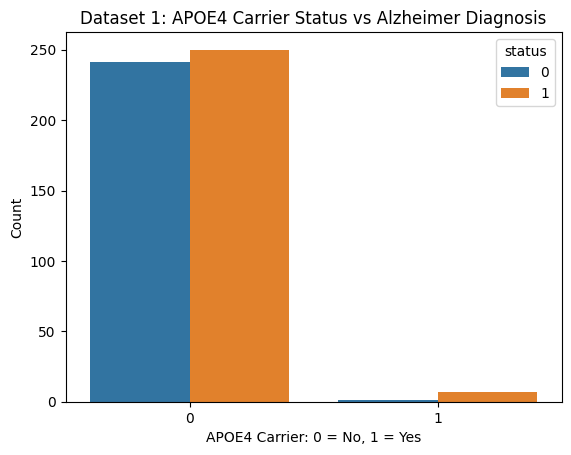

In [ ]:
# Use detected columns
apoe_col = possible_apoe[0]
diagnosis_col = possible_diag[0]

apoe["APOE4_carrier"] = apoe[apoe_col].astype(str).str.contains("4", case=False, na=False).astype(int)

print(pd.crosstab(apoe["APOE4_carrier"], apoe[diagnosis_col], normalize="index"))

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=apoe, x="APOE4_carrier", hue=diagnosis_col)
plt.title("Dataset 1: APOE4 Carrier Status vs Alzheimer Diagnosis")
plt.xlabel("APOE4 Carrier: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

In [ ]:
# Logistic regression: Does APOE4 predict Alzheimer/disease status?
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Convert diagnosis to binary if needed
y = pd.factorize(apoe[diagnosis_col])[0]
X = apoe[["APOE4_carrier"]]

model = LogisticRegression()
model.fit(X, y)

print("Coefficient for APOE4:", model.coef_[0][0])
print("Interpretation: positive coefficient means APOE4 is associated with higher disease probability.")

Coefficient for APOE4: -1.0261535238727741
Interpretation: positive coefficient means APOE4 is associated with higher disease probability.


In [ ]:
# =========================
# STEP 6: Dataset 2 analysis
# Cholesterol/lifestyle factors vs Alzheimer diagnosis
# =========================

print(alz.columns.tolist())

# Look for useful columns
for col in alz.columns:
    if any(word in col.lower() for word in ["cholesterol", "bmi", "diet", "physical", "diagnosis", "memory", "functional"]):
        print(col, alz[col].head())

['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']
BMI 0    22.927749
1    26.827681
2    17.795882
3    33.800817
4    20.716974
Name: BMI, dtype: float64
PhysicalActivity 0    6.327112
1    7.619885
2    7.844988
3    8.428001
4    6.310461
Name: PhysicalActivity, dtype: float64
DietQuality 0    1.347214
1    0.518767
2    1.826335
3    7.435604
4    0.795498
Name: DietQuality, dtype: float64
CholesterolTotal 0    242.366840
1    231.162595
2    284.181858
3  

In [ ]:
# Usually this dataset has columns like:
# CholesterolTotal, CholesterolLDL, CholesterolHDL, CholesterolTriglycerides, Diagnosis
# Adjust names if your printed columns differ.

target = "Diagnosis"

features = [
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "BMI",
    "PhysicalActivity",
    "DietQuality",
    "MemoryComplaints",
    "FunctionalAssessment"
]

features = [f for f in features if f in alz.columns]
print("Using features:", features)

data2 = alz[features + [target]].dropna()

X = data2[features]
y = data2[target]

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("AUC:", roc_auc_score(y_test, prob))

Using features: ['CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'BMI', 'PhysicalActivity', 'DietQuality', 'MemoryComplaints', 'FunctionalAssessment']
              precision    recall  f1-score   support

           0       0.74      0.78      0.76       278
           1       0.56      0.51      0.53       152

    accuracy                           0.68       430
   macro avg       0.65      0.65      0.65       430
weighted avg       0.68      0.68      0.68       430

AUC: 0.7414804998106778


                    Feature  Importance
8      FunctionalAssessment    0.251653
7          MemoryComplaints    0.098070
0          CholesterolTotal    0.096755
5          PhysicalActivity    0.096096
6               DietQuality    0.094416
3  CholesterolTriglycerides    0.092565
2            CholesterolHDL    0.091715
4                       BMI    0.090787
1            CholesterolLDL    0.087942


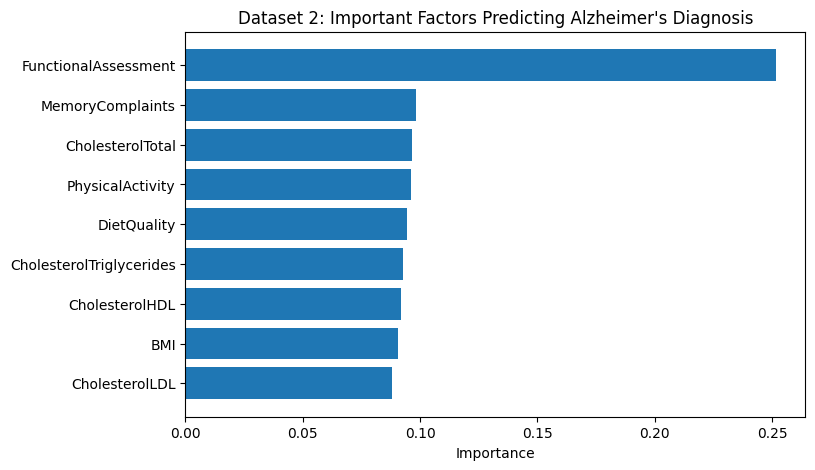

In [ ]:
# Feature importance plot
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Dataset 2: Important Factors Predicting Alzheimer's Diagnosis")
plt.xlabel("Importance")
plt.show()

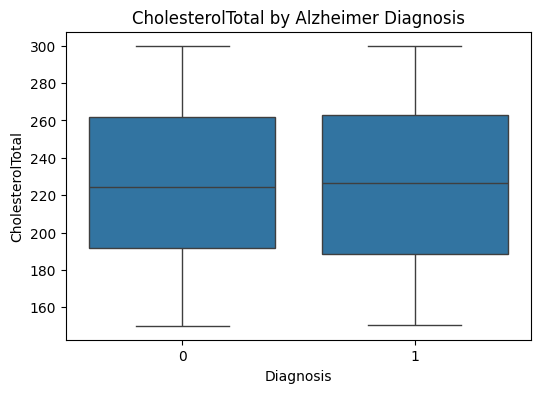

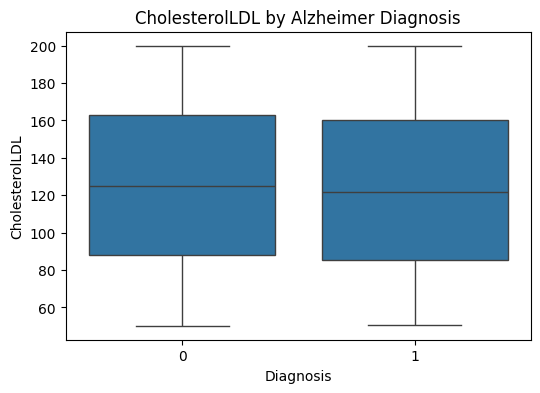

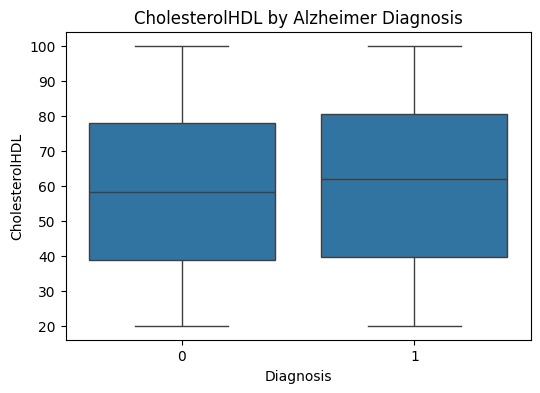

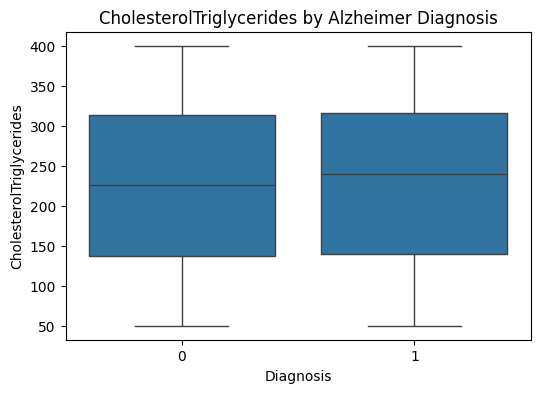

In [ ]:
# Compare cholesterol between Alzheimer vs non-Alzheimer groups
chol_cols = [c for c in alz.columns if "Cholesterol" in c]

for c in chol_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=alz, x="Diagnosis", y=c)
    plt.title(f"{c} by Alzheimer Diagnosis")
    plt.show()

In [ ]:
# =========================
# STEP 7: Dataset 4 analysis
# Cognitive decline/MRI brain measures vs dementia
# =========================

print(dem.columns.tolist())
print(dem.head())

# Common columns: Group, M/F, Age, EDUC, SES, MMSE, CDR, eTIV, nWBV, ASF

['Subject_ID', 'MRI_ID', 'Group', 'Visit', 'MR_Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
  Subject_ID         MRI_ID        Group  Visit  MR_Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  


In [ ]:
# Clean dementia dataset
dem2 = dem.copy()

# Remove converted group if present or keep all groups
print(dem2["Group"].value_counts())

# Convert Group into binary: Demented = 1, Nondemented = 0
dem2 = dem2[dem2["Group"].isin(["Demented", "Nondemented"])].copy()
dem2["Dementia_binary"] = dem2["Group"].map({"Nondemented": 0, "Demented": 1})

features4 = ["Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
features4 = [f for f in features4 if f in dem2.columns]

data4 = dem2[features4 + ["Dementia_binary"]].dropna()

X = data4[features4]
y = data4["Dementia_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf4 = RandomForestClassifier(random_state=42)
rf4.fit(X_train, y_train)

pred4 = rf4.predict(X_test)
prob4 = rf4.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred4))
print("AUC:", roc_auc_score(y_test, prob4))

Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        26

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64

AUC: 1.0


  Feature  Importance
4     CDR    0.564100
3    MMSE    0.208667
6    nWBV    0.069317
5    eTIV    0.038090
7     ASF    0.037957
1    EDUC    0.032779
0     Age    0.029197
2     SES    0.019895


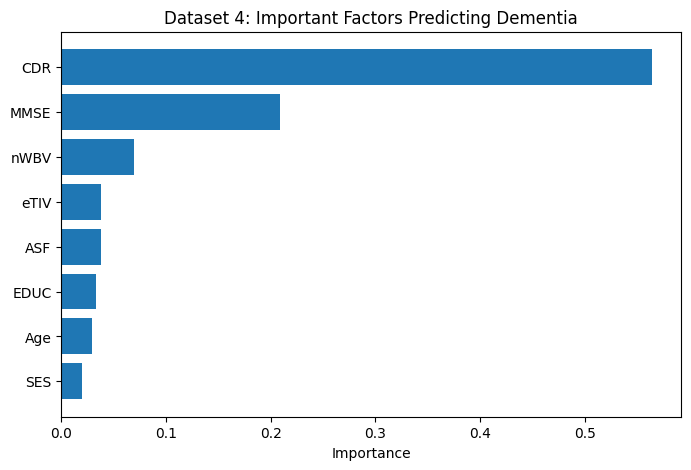

In [ ]:
# Feature importance for dementia
importance4 = pd.DataFrame({
    "Feature": features4,
    "Importance": rf4.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance4)

plt.figure(figsize=(8,5))
plt.barh(importance4["Feature"], importance4["Importance"])
plt.gca().invert_yaxis()
plt.title("Dataset 4: Important Factors Predicting Dementia")
plt.xlabel("Importance")
plt.show()

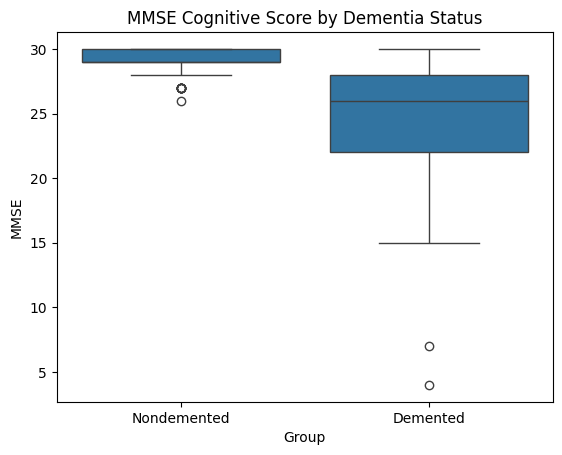

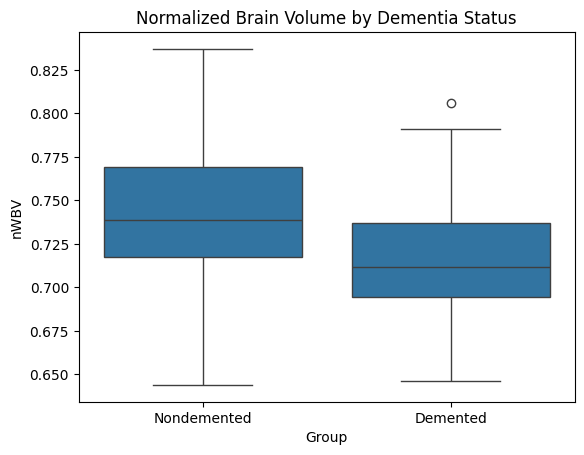

In [ ]:
# MMSE and brain volume comparison
sns.boxplot(data=dem2, x="Group", y="MMSE")
plt.title("MMSE Cognitive Score by Dementia Status")
plt.show()

sns.boxplot(data=dem2, x="Group", y="nWBV")
plt.title("Normalized Brain Volume by Dementia Status")
plt.show()